<ol>
  <li>Cell 1：讀取福壽原始資料</li>
  <li>Cell 2：欄位清理與目標體重欄位建立</li>
  <li>Cell 3：建立 <code>Age</code> / 日齡欄位</li>
  <li>Cell 4：建立 <code>batch_id</code> / 生長曲線識別欄位</li>
  <li>Cell 5：檢查每條生長曲線</li>
  <li>Cell 6：篩選有效曲線</li>
  <li>Cell 7：建立福壽 daily statistics</li>
  <li>Cell 8：視覺化生長曲線</li>
  <li>Cell 9：匯出 CSV</li>
</ol>

In [1]:
import os
import pandas as pd
import random
import shutil
import numpy as np
import pickle

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [3]:
# === Step 1. 設定 scaler 模式 ===
SCALER_MODE = "fit0_31"
# 可選：
# "fit0_31"：福壽 0~31 自己 fit scaler/福壽 0~31 全資料 fit scaler（前期實驗版）
# "reuse0_21" ：沿用福壽 0~21 已 fit 好的 scaler

In [4]:
from pathlib import Path
output_dir = Path(f"0~31日齡_{SCALER_MODE}_scaler")
output_dir.mkdir(parents=True, exist_ok=True)

<h3> Definition函式 </h3>

In [5]:
def daily_features(group):
    
    """
    對單日的資料進行聚合，計算統計特徵，用於後續建模或分析。
        包含該群組的統計特徵：
        - min     : 最小值
        - max     : 最大值
        - range   : 變動範圍 (max - min)
        - p25     : 第 25 百分位數（Q1）
        - p75     : 第 75 百分位數（Q3）
        - IQR     : 四分位距 (Q3 - Q1)，衡量數據分散度
        - median  : 中位數
        - std     : 標準差，衡量數據波動
        - mean    : 平均數（這裡同時作為 label，用於監督式學習）
    """
    
    return pd.Series({
        "min": group.min(),
        "max": group.max(),
        "range": group.max() - group.min(),
        "p25": np.percentile(group, 25),
        "p75": np.percentile(group, 75),
        "IQR": np.percentile(group, 75) - np.percentile(group, 25),
        "median": np.median(group),
        "std": group.std(),
        "mean": group.mean()   # 這就是 label
    })

In [6]:
def plot_growth_curves(df, standard_data=None, ages=None, show_standard=True):
    """
    畫出各批次 (chicken_import_id) 和棟舍 (building_number) 的生長曲線，
    並可選擇是否對照 ROSS 308 標準生長數據。

    參數:
        df : DataFrame
            必須包含 ['chicken_import_id', 'building_number', 'age', 'avg_weight']
        standard_data : list (optional)
            ROSS 308 標準生長數據，長度應與 ages 相符
        ages : list (optional)
            日齡 (通常 0-35)
        show_standard : bool
            是否顯示 ROSS 308 標準生長數據，預設 True
    """

    # 預設 ROSS 308 標準數據
    if standard_data is None:
        standard_data = [43,61,79,99,122,148,176,208,242,280,321,366,414,465,519,
                         576,637,701,768,837,910,985,1062,1142,1225,1309,1395,1483,
                         1573,1664,1757,1851,1946,2041,2138,2235]
    if ages is None:
        ages = list(range(0, len(standard_data)))  # 自動對應標準數據的長度

    grouped = df.groupby(['chicken_import_id', 'building_number']) # 分組繪製

    plt.figure(figsize=(25, 15))
    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 解決中文顯示
    plt.rcParams['axes.unicode_minus'] = False  # 解決座標軸負號顯示

    # 畫每一個批次 + 棟舍
    for (chicken_import_id, building_number), group_data in grouped:
        group_data = group_data.sort_values('age')  # 按日齡排序
        plt.plot(group_data['age'], group_data['avg_weight'], alpha=0.7, 
                 label=f'批次 {chicken_import_id}, 棟舍 {building_number}')

    # 是否畫標準曲線
    if show_standard:
        plt.plot(ages, standard_data, color='black', linestyle='--', linewidth=2, 
             label='ROSS 308 標準生長曲線') # 添加 ROSS 308 標準生長曲線

    # 圖表標題與標籤
    plt.title('按批次及棟舍的重量增長趨勢')
    plt.xlabel('日齡')
    plt.ylabel('重量')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # 圖例放到右邊
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [7]:
# 讀取用戶上傳的CSV檔案
file_path = 'breeding_logs.csv'

# 欄位名稱
columns = [
    'id', 'contract_id', 'chicken_import_id', 'building_number', 'date', 'age', 
    'disuse', 'breeding_rate', 'am_avg_weight', 'pm_avg_weight', 'creator', 
    'last_editor', 'modified_log', 'created_at', 'updated_at'
]

# 讀取CSV檔案，並加入指定的欄位名稱
df = pd.read_csv(file_path, header=None, names=columns)

# 顯示前幾筆資料來確認讀取成功
df

,id,contract_id,chicken_import_id,building_number,date,age,disuse,breeding_rate,am_avg_weight,pm_avg_weight,creator,last_editor,modified_log,created_at,updated_at
0,35,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11212102,A棟上層,2023-12-11,0,0,1.02,\N,33,\N,\N,\N,2024-06-14 03:36:50,2024-07-13 07:04:17
1,36,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11212102,A棟上層,2023-12-12,1,0,1.02,34,35,\N,\N,\N,2024-06-14 03:36:50,2024-07-13 07:04:17
2,37,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11212102,A棟上層,2023-12-13,2,0,1.02,36,38,\N,\N,\N,2024-06-14 03:36:50,2024-07-13 07:04:17
3,38,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11212102,A棟上層,2023-12-14,3,0,1.02,42,45,\N,\N,\N,2024-06-14 03:36:50,2024-07-13 07:04:17
4,39,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11212102,A棟上層,2023-12-15,4,0,1.02,56,73,\N,\N,\N,2024-06-14 03:36:50,2024-07-13 07:04:17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1709,1760,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11303103,上層,2024-03-27,11,0,1.02,285,319,\N,\N,\N,2024-07-12 04:25:23,2024-07-12 04:25:23
1710,1761,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11303103,上層,2024-03-28,12,0,1.02,338,374,\N,\N,\N,2024-07-12 04:25:23,2024-07-12 04:25:23
1711,1762,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11303103,上層,2024-03-29,13,0,1.02,389,429,\N,\N,\N,2024-07-12 04:25:23,2024-07-12 04:25:23
1712,1763,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11303103,上層,2024-03-30,14,0,1.02,448,493,\N,\N,\N,2024-07-12 04:25:23,2024-07-12 04:25:23


In [8]:
# Dropping the unnecessary columns as specified by the user
columns_to_drop = ['id', 'creator', 'last_editor', 'modified_log', 'created_at', 'updated_at', 'date', 'disuse', 'breeding_rate'] # 'contract_id', 
df = df.drop(columns=columns_to_drop)
df

,contract_id,chicken_import_id,building_number,age,am_avg_weight,pm_avg_weight
0,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11212102,A棟上層,0,\N,33
1,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11212102,A棟上層,1,34,35
2,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11212102,A棟上層,2,36,38
3,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11212102,A棟上層,3,42,45
4,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11212102,A棟上層,4,56,73
...,...,...,...,...,...,...
1709,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11303103,上層,11,285,319
1710,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11303103,上層,12,338,374
1711,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11303103,上層,13,389,429
1712,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11303103,上層,14,448,493


In [9]:
# 查看缺失值，篩選出 'am_avg_weight' 及 'pm_avg_weight' 皆為空值或0的行。
filtered_df = df[
    ((df['am_avg_weight'] == "\\N") | (df['am_avg_weight'] == "0")) &
    ((df['pm_avg_weight'] == "\\N") | (df['pm_avg_weight'] == "0"))
]

filtered_df

,contract_id,chicken_import_id,building_number,age,am_avg_weight,pm_avg_weight
130,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,32,\N,\N
131,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,33,\N,\N
132,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,34,\N,\N
133,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,35,\N,\N
1084,eef47f04-01e7-4b49-8827-e231694ea345,G11303104,上層,34,\N,\N
...,...,...,...,...,...,...
1388,ac9f83ba-6c2f-4e40-ae65-e4593ddab5bf,G11304103,三場,31,\N,\N
1389,ac9f83ba-6c2f-4e40-ae65-e4593ddab5bf,G11304103,三場,32,\N,\N
1390,ac9f83ba-6c2f-4e40-ae65-e4593ddab5bf,G11304103,三場,33,\N,\N
1391,ac9f83ba-6c2f-4e40-ae65-e4593ddab5bf,G11304103,三場,34,\N,\N


In [10]:
# 並且依據chicken_import_id及building_number群組，計算各別所缺失的資料數量。
#   => 需要補齊資料，若該雞隻的資料缺失太多，則丟棄。

# 按 'age' 排序並選取每個 'chicken_import_id' 和 'building_number' 組合的最後一筆資料
last_age_df = filtered_df.sort_values('age').drop_duplicates(subset=['chicken_import_id', 'building_number'], keep='last')

# 新增一個欄位來計算每個 'chicken_import_id' 和 'building_number' 組合的資料數量
last_age_df['data_count'] = filtered_df.groupby(['chicken_import_id', 'building_number'])['age'].transform('count')

# 顯示結果
# last_age_df.drop(columns=['am_avg_weight',	'pm_avg_weight', 'age']).reset_index(drop=True)
last_age_df.drop(columns=['am_avg_weight',	'pm_avg_weight'])

,contract_id,chicken_import_id,building_number,age,data_count
1295,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11305106,下層,8,1
1220,eef47f04-01e7-4b49-8827-e231694ea345,G11303104,下層,35,2
1085,eef47f04-01e7-4b49-8827-e231694ea345,G11303104,上層,35,2
133,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,35,4
1356,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11301101,上層,35,36
1392,ac9f83ba-6c2f-4e40-ae65-e4593ddab5bf,G11304103,三場,35,36


<ol> 計算這隻雞總共缺幾次。
    <li> 針對 filtered_df（所有缺失），計算每隻雞 (chicken_import_id, building_number) 的 缺失筆數。 </li>
    <li> 表格裡的 data_count 就是「這隻雞在所有日齡裡，一共缺失多少次」。 </li>
</ol>

<h3> 遇到缺失值的處理方式 </h3> 
<ol>
    <li> 先去系統查看是否真的缺少均重資料。（有可能使用者沒有儲存到均重資料。） </li>
    <li> 從表中我們可以看到有些資料缺失太多，幾乎是沒有任何重量資料，應當刪除。 </li>
        <p> A11301101	上層 </p>
        <p> G11304103	三場 </p>
    <li> 其餘資料則找是否有相同的批號（可以不同棟舍）來填補缺失值。 </li>
    
</ol>

<p> Hint: 探索不同的資料補齊方法，例如使用統計方法來填補缺失資料。 </p>

In [11]:
# 一次刪除多筆特定的 chicken_import_id 和 building_number 組合
# 構建要刪除的條件
delete_conditions = [
    ('A11301101', '上層'),
    ('G11304103', '三場')
]

# 將條件轉換為 DataFrame 以便進行匹配
conditions_df = pd.DataFrame(delete_conditions, columns=['chicken_import_id', 'building_number'])

# 使用 merge 來進行篩選，刪除符合條件的資料
df = df.merge(conditions_df, on=['chicken_import_id', 'building_number'], how='outer', indicator=True)
df = df[df['_merge'] == 'left_only'].drop(columns=['_merge'])

df

,contract_id,chicken_import_id,building_number,age,am_avg_weight,pm_avg_weight
36,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,0,\N,41
37,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,1,52,58
38,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,2,64,72
39,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,3,84,90
40,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,4,90,88
...,...,...,...,...,...,...
1709,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,29,1617,1684
1710,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,30,1725,1770
1711,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,31,1749,1834
1712,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,32,1777,1882


In [12]:
# 新增'avg_weight'欄位的邏輯
# 先看下午均重，如果合理就用；不合理再看上午均重；如果兩個都不行就設 None，最後把結果轉成數字並存成 avg_weight，再刪掉原始的上午/下午欄位。
df['avg_weight'] = df.apply(
    lambda row: row['pm_avg_weight'] if pd.notnull(row['pm_avg_weight']) and row['pm_avg_weight'] != "\\N" and row['pm_avg_weight'] != "0"
    else row['am_avg_weight'] if pd.notnull(row['am_avg_weight']) and row['am_avg_weight'] != "\\N" and row['am_avg_weight'] != "0"
    else None, axis=1
)

# 將'avg_weight'轉換為數值型態
# errors='coerce' 的意思是，如果遇到無法轉換為數字的值（例如字母或特殊符號），Pandas 會將該值轉換為 NaN（空值），而不會拋出錯誤。
df['avg_weight'] = pd.to_numeric(df['avg_weight'], errors='coerce')

# 刪除'am_avg_weight'和'pm_avg_weight'欄位
df = df.drop(columns=['am_avg_weight', 'pm_avg_weight'])

df

,contract_id,chicken_import_id,building_number,age,avg_weight
36,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,0,41.0
37,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,1,58.0
38,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,2,72.0
39,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,3,90.0
40,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,4,88.0
...,...,...,...,...,...
1709,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,29,1684.0
1710,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,30,1770.0
1711,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,31,1834.0
1712,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,32,1882.0


------------------------

<h2> 逐筆處理缺失值 </h2>

<p style='color:blue'>◆ chicken_import_id為A11305106的資料 </p>

In [13]:
#  chicken_import_id為A11305106的資料
# 搜尋 'chicken_import_id' 為 'A11305106' 且 'age' 為 8 的資料
search_result = df[(df['chicken_import_id'] == 'A11305106') & (df['avg_weight'].isnull())]
search_result

,contract_id,chicken_import_id,building_number,age,avg_weight
78,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11305106,下層,8,NaN


In [14]:
# df[(df['chicken_import_id'] == 'A11305106')].reset_index(drop=True)

<p> 由於A11305106批號僅有下層資料，因此改以前後歲數(7歲&9歲)取平均值來填補缺失值。 </p>

<p> 前後插值（Interpolation）: 對於時間序列數據，可以用異常值前後的數據點進行插值來替代異常值。  </p>

In [15]:
# 找出 chicken_import_id為A11305106 且 age分別為7歲與9歲
df[(df['chicken_import_id'] == 'A11305106') & (df['age'].isin([7, 9]))]

,contract_id,chicken_import_id,building_number,age,avg_weight
77,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11305106,下層,7,135.0
79,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11305106,下層,9,227.0


In [16]:
# 計算7歲與9歲的平均數
df[(df['chicken_import_id'] == 'A11305106') & (df['age'].isin([7, 9]))]['avg_weight'].mean()

181.0

In [17]:
# 填補'age' 為 8 的缺失值
df.loc[ (df['chicken_import_id'] == 'A11305106') & (df['age'] == 8), 'avg_weight' ] = df[(df['chicken_import_id'] == 'A11305106') & (df['age'].isin([7, 9]))]['avg_weight'].mean()
df[(df['chicken_import_id'] == 'A11305106') & (df['building_number'] == "下層")]

,contract_id,chicken_import_id,building_number,age,avg_weight
70,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11305106,下層,0,20.0
71,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11305106,下層,1,23.0
72,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11305106,下層,2,28.0
73,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11305106,下層,3,46.0
74,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11305106,下層,4,65.0
75,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11305106,下層,5,90.0
76,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11305106,下層,6,112.0
77,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11305106,下層,7,135.0
78,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11305106,下層,8,181.0
79,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11305106,下層,9,227.0


<p style='color:blue'>◆ chicken_import_id為G11303104的資料 </p>

In [18]:
#  搜尋 chicken_import_id為G11303104 且 avg_weight為null 的資料
search_result = df[(df['chicken_import_id'] == 'G11303104') & (df['avg_weight'].isnull())]
search_result

,contract_id,chicken_import_id,building_number,age,avg_weight
1372,eef47f04-01e7-4b49-8827-e231694ea345,G11303104,上層,34,NaN
1373,eef47f04-01e7-4b49-8827-e231694ea345,G11303104,上層,35,NaN
1408,eef47f04-01e7-4b49-8827-e231694ea345,G11303104,下層,34,NaN
1409,eef47f04-01e7-4b49-8827-e231694ea345,G11303104,下層,35,NaN


<p> 由於G11303104批號在雞隻第33歲的時候就收雞了，因此不會有第34歲及第35歲的資料。 </p>

In [19]:
# 移除 'chicken_import_id' 為 'G11303104' 且 'avg_weight' 為空值的資料
df = df[~((df['chicken_import_id'] == 'G11303104') & (df['avg_weight'].isnull()))]
df

,contract_id,chicken_import_id,building_number,age,avg_weight
36,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,0,41.0
37,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,1,58.0
38,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,2,72.0
39,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,3,90.0
40,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,4,88.0
...,...,...,...,...,...
1709,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,29,1684.0
1710,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,30,1770.0
1711,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,31,1834.0
1712,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,32,1882.0


<p style='color:blue'>◆ chicken_import_id為G11302101的資料 </p>

In [20]:
#  搜尋 chicken_import_id為G11302101的資料
search_result = df[(df['chicken_import_id'] == 'G11302101') & (df['avg_weight'].isnull())]
search_result

,contract_id,chicken_import_id,building_number,age,avg_weight
945,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,32,NaN
946,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,33,NaN
947,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,34,NaN
948,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,35,NaN


In [21]:
df[(df['chicken_import_id'] == 'G11302101') & (df['building_number'] == 'B棟上層')].reset_index(drop=True)

,contract_id,chicken_import_id,building_number,age,avg_weight
0,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,0,38.0
1,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,1,53.0
2,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,2,68.0
3,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,3,80.0
4,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,4,102.0
5,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,5,146.0
6,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,6,182.0
7,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,7,171.0
8,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,8,198.0
9,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,9,232.0


<p> 由於G11302101批號在雞隻第31歲的時候就收雞了，因此也不會之後的資料。 </p>

In [22]:
# 移除 'chicken_import_id' 為 'G11302101' 且 'avg_weight' 為空值的資料
df = df[~((df['chicken_import_id'] == 'G11302101') & (df['avg_weight'].isnull()))]
df

,contract_id,chicken_import_id,building_number,age,avg_weight
36,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,0,41.0
37,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,1,58.0
38,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,2,72.0
39,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,3,90.0
40,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,4,88.0
...,...,...,...,...,...
1709,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,29,1684.0
1710,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,30,1770.0
1711,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,31,1834.0
1712,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,32,1882.0


------------------------------------------

<h3> 另外G11303103批號、上層棟舍 資料異常，雞隻歲數僅34歲，卻有51筆資料。 </h3>

In [23]:
df[(df['chicken_import_id'] == 'G11303103') & (df['building_number'] == '上層')].count()

contract_id          51
chicken_import_id    51
building_number      51
age                  51
avg_weight           51
dtype: int64

<p> 因為有重複值的關係，需要篩除重複值。 </p>

In [24]:
# 去除重複值，依據 contract_id, chicken_import_id, building_number, age, avg_weight 篩選
df = df.drop_duplicates(subset=['contract_id', 'chicken_import_id', 'building_number', 'age', 'avg_weight'])
df

,contract_id,chicken_import_id,building_number,age,avg_weight
36,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,0,41.0
37,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,1,58.0
38,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,2,72.0
39,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,3,90.0
40,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,4,88.0
...,...,...,...,...,...
1709,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,29,1684.0
1710,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,30,1770.0
1711,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,31,1834.0
1712,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,32,1882.0


---------------------------------

In [25]:
# 檢查是否仍有缺失值。
df.isnull().sum()

contract_id          0
chicken_import_id    0
building_number      0
age                  0
avg_weight           0
dtype: int64

<h3> 視覺化：將每一個批號及棟舍畫出趨勢圖 </h3>
<ol>
    <li> 觀察是否能直接透過雞隻體重來做預測。 </li>
    <li> 詢問ChatGPT這樣的趨勢圖是否適合使用LSTM來作預測及成效如何。 </li>
</ol>

<p> 加入 "ROSS308標準生長曲線" 最為比較基準(BenchMark)。 </p>

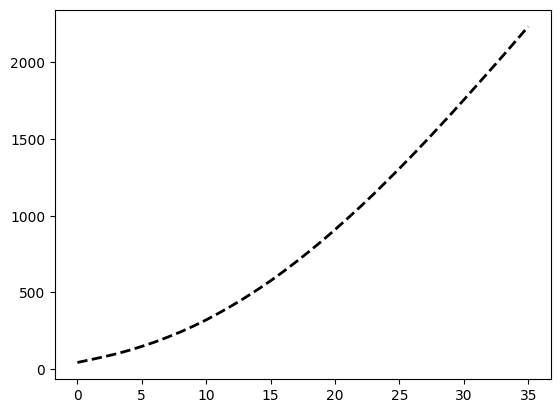

In [26]:
# ROSS 308 標準生長數據
standard_data = [43,61,79,99,122,148,176,208,242,280,321,366,414,465,519,576,637,701,768,837,910,985,1062,1142,1225,1309,1395,1483,1573,1664,1757,1851,1946,2041,2138,2235]
ages = list(range(0, 36))  # 0-35日齡

# 添加 ROSS 308 標準生長曲線
plt.plot(ages, standard_data, color='black', linestyle='--', linewidth=2, label='ROSS 308 標準生長曲線')

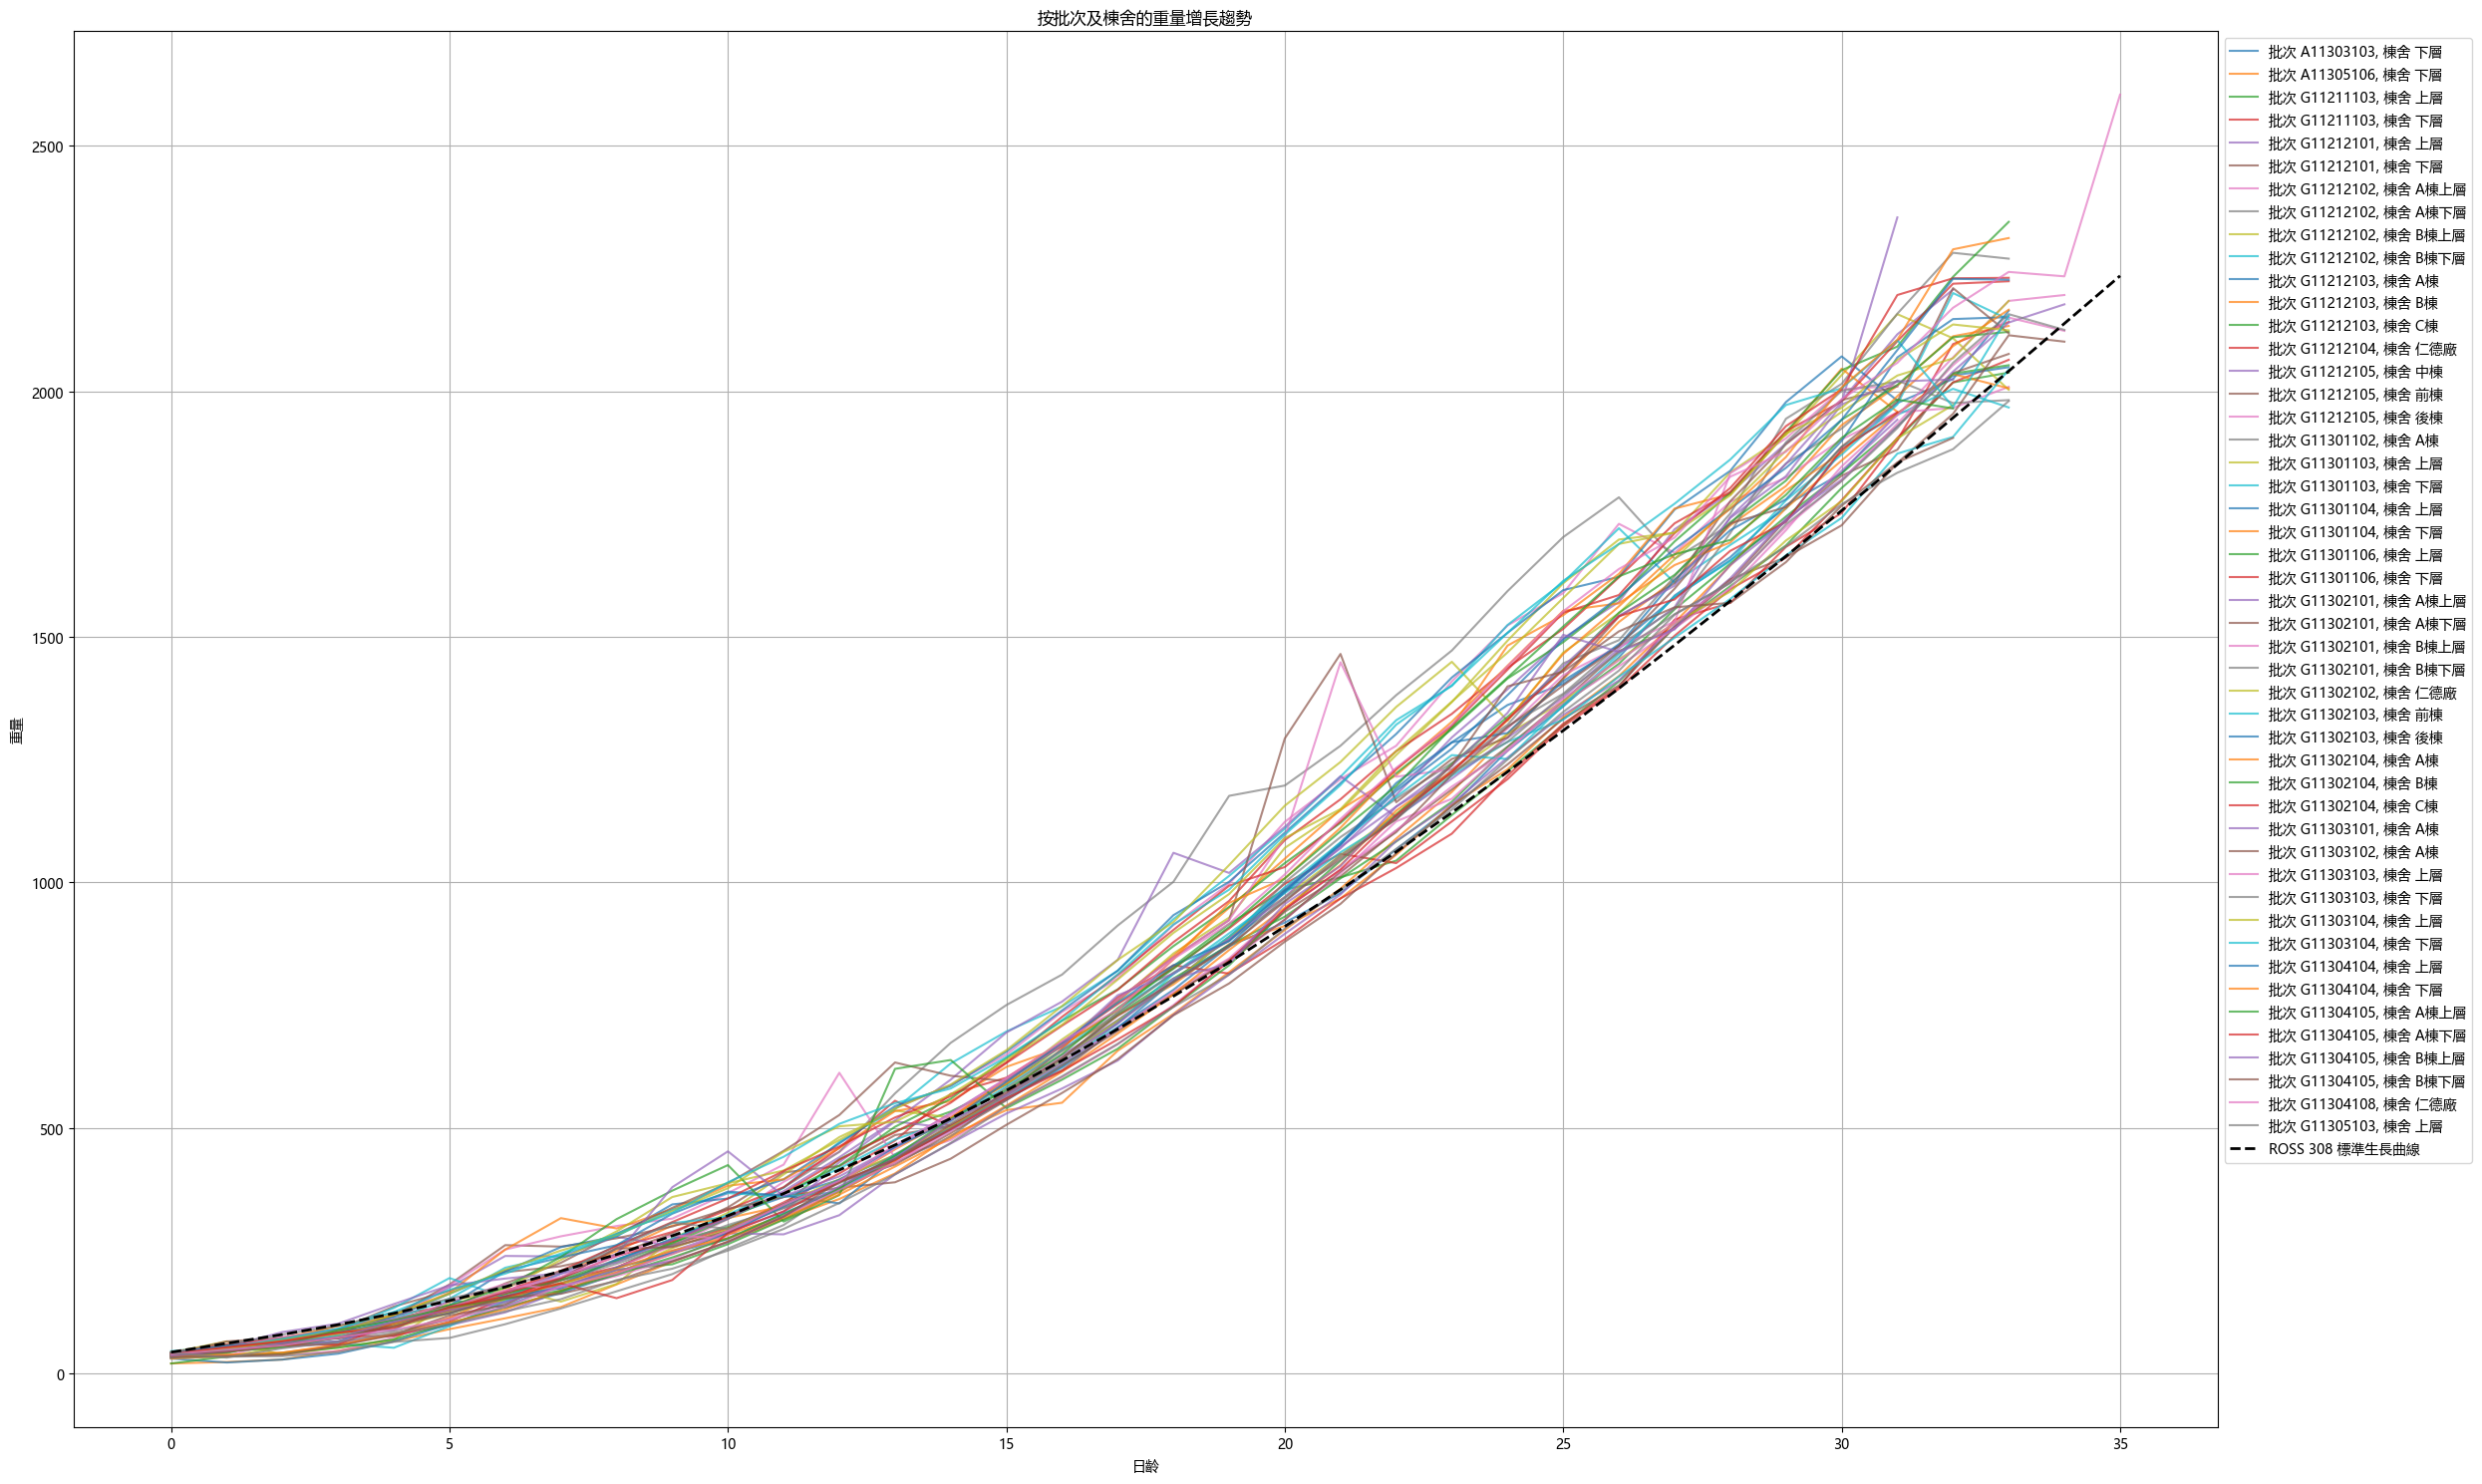

In [27]:
plot_growth_curves(df)  # 用預設的 ROSS 308 標準數據

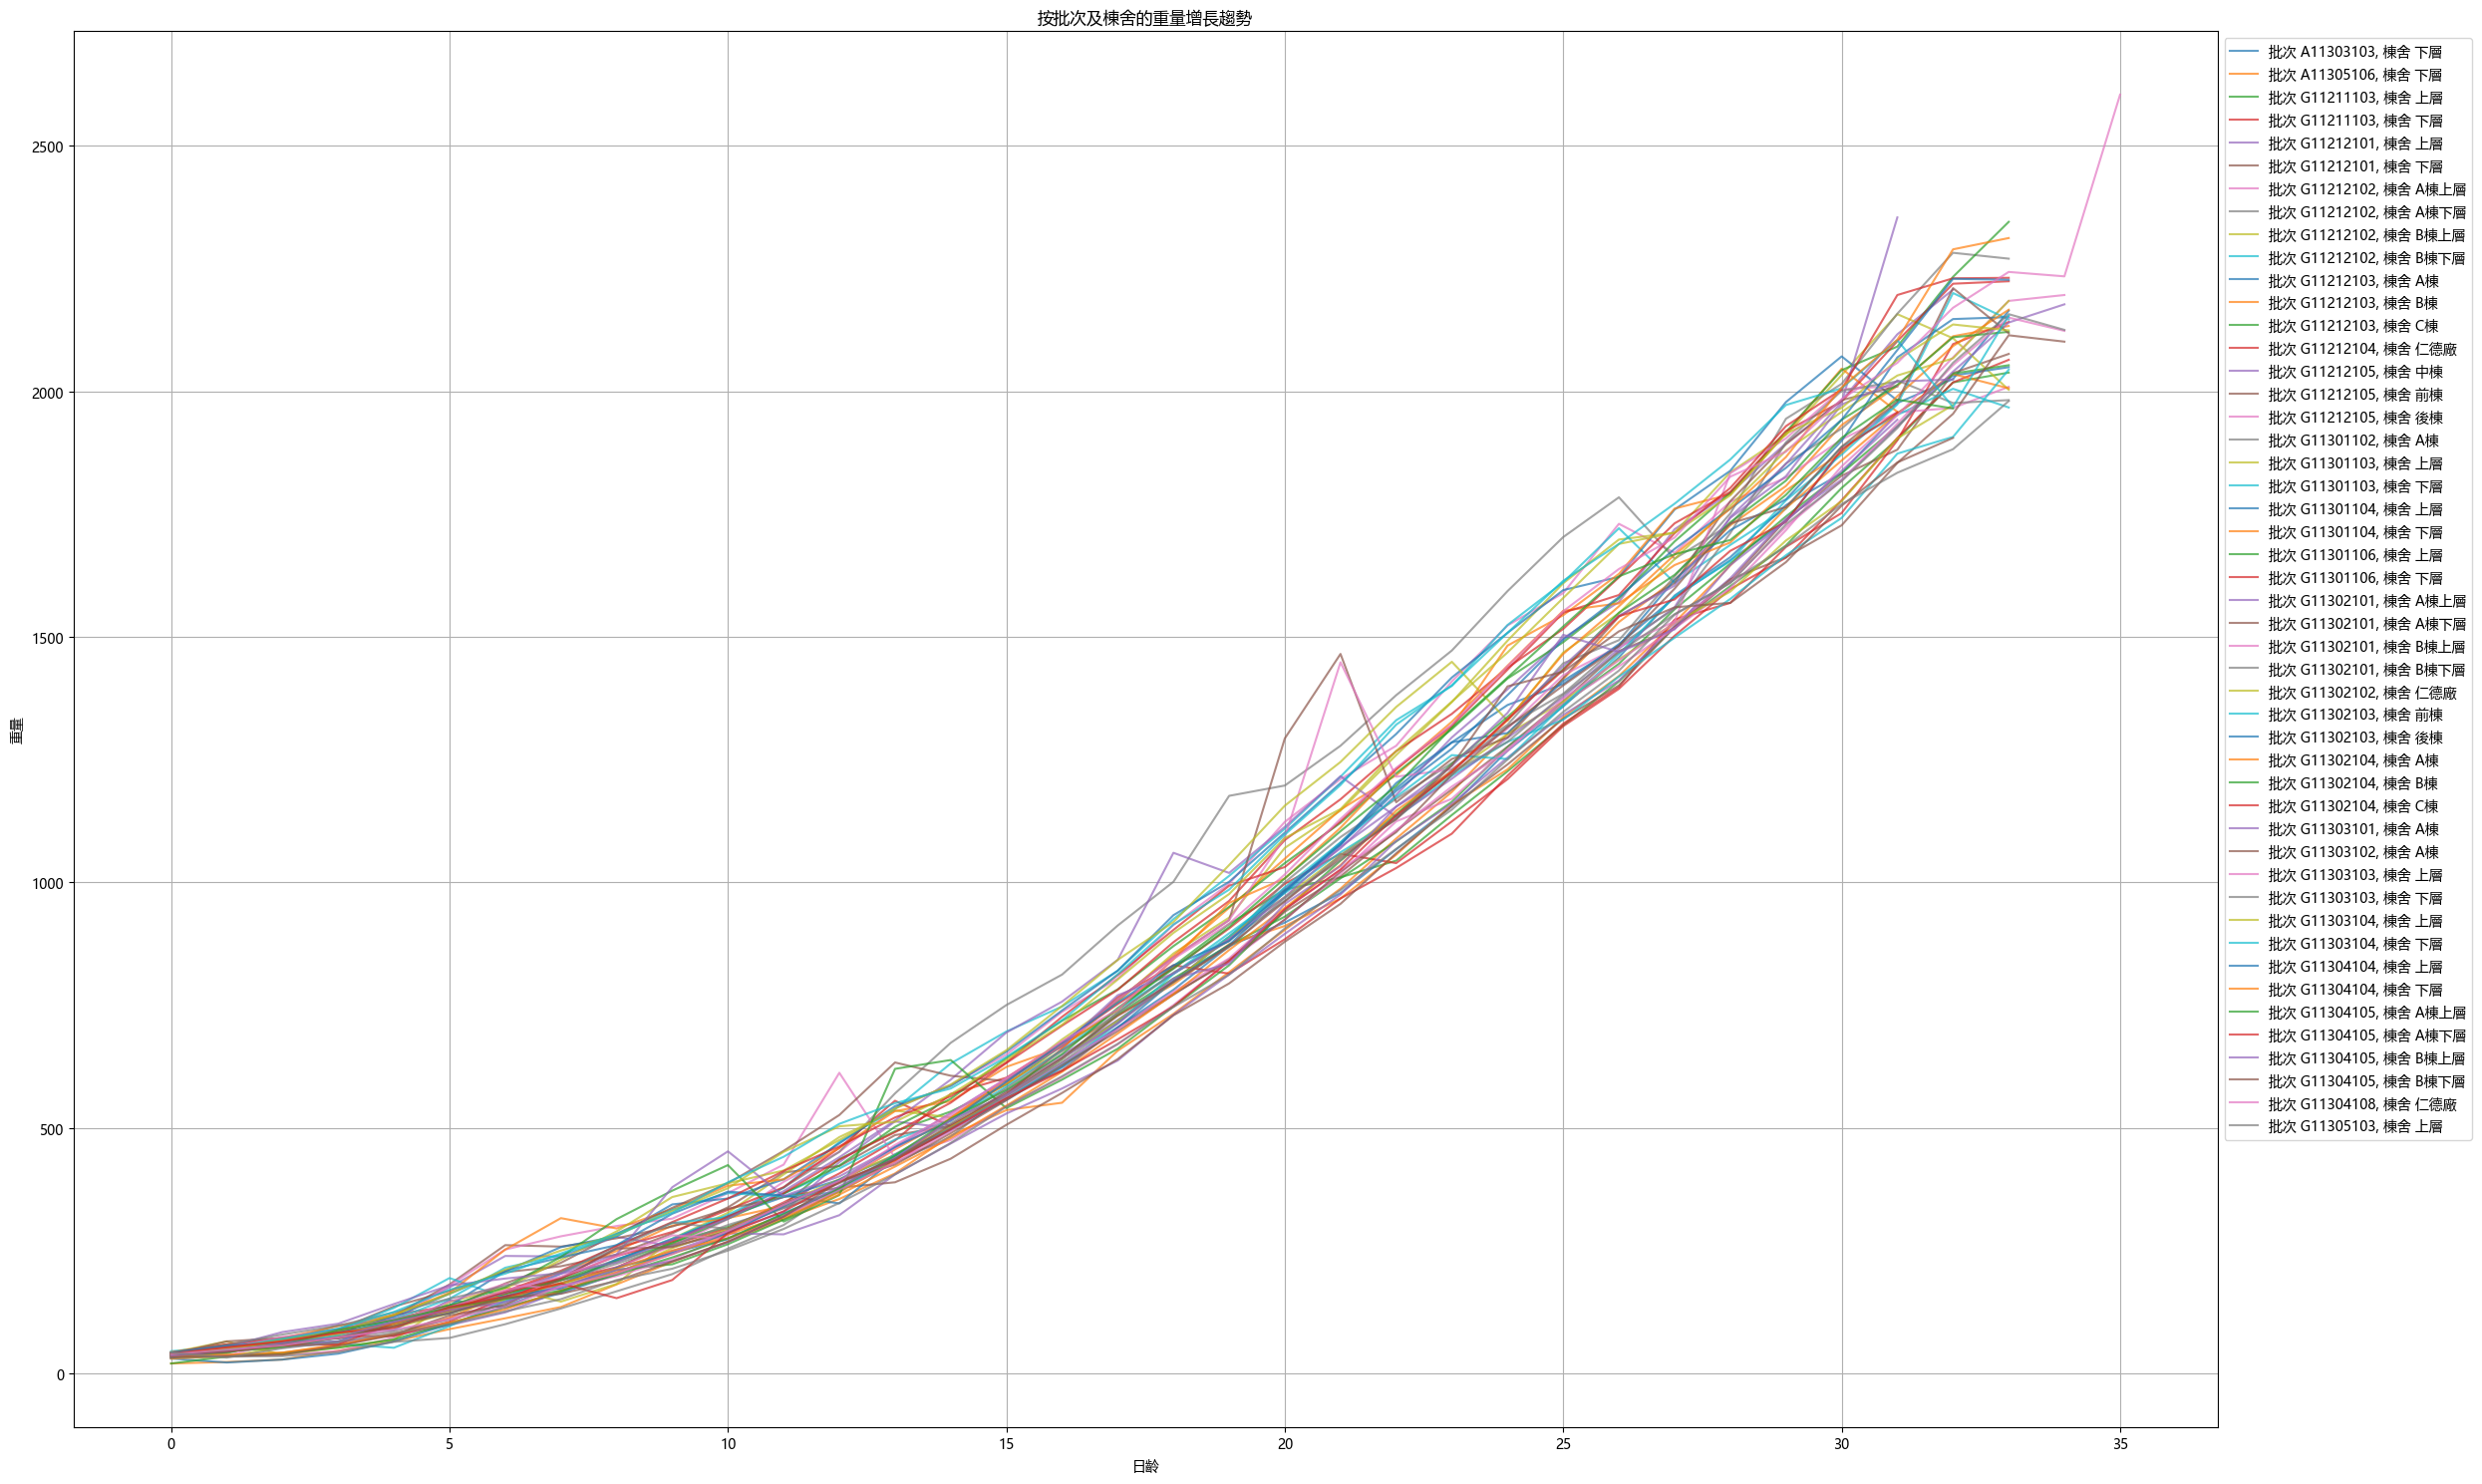

In [28]:
plot_growth_curves(df, show_standard=False)  # 用預設的 ROSS 308 標準數據

<h3> 繪製箱型圖 </h3>
<p> 使用箱型圖可以視覺化數據的分佈，包括數據的中位數、四分位數範圍、異常值等。不同批次之間的箱型圖可以清晰地展示數據的</p><p style="color:red">變異性。 </p>

<Figure size 4500x4500 with 0 Axes>

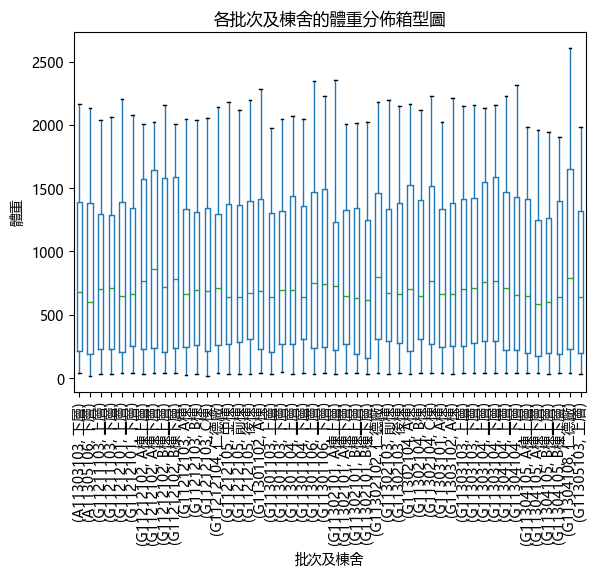

In [29]:
# 繪製箱型圖來顯示變異性
plt.figure(figsize=(45, 45))
df.boxplot(column='avg_weight', by=['chicken_import_id', 'building_number'], grid=False)
plt.title('各批次及棟舍的體重分佈箱型圖')
plt.suptitle('')  # 刪除預設的副標題
plt.xlabel('批次及棟舍')
plt.ylabel('體重')
plt.xticks(rotation=90, fontsize=10)  # 將 X 軸標籤旋轉並調整字體大小
plt.show()

<h2> 統一截取 0~31 日齡的均重 </h2>
<P> time window alignment（時間視窗對齊） </P>

In [30]:
# 依據 chicken_import_id 及 building_number分組，知道每一組最大歲數。
max_age_per_group = df.groupby(['chicken_import_id', 'building_number'])['age'].max().reset_index()
# max_age_per_group
max_age_per_group['age'].min()

31

<h3> 歲數最小值為31歲，因此統一取0歲~31歲的資料作為訓練&測試資料集。 </h3>

In [31]:
df = df[df["age"].between(0, 31)].copy() # df = df[~((df['age']>31))]
df

,contract_id,chicken_import_id,building_number,age,avg_weight
36,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,0,41.0
37,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,1,58.0
38,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,2,72.0
39,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,3,90.0
40,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,4,88.0
...,...,...,...,...,...
1707,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,27,1545.0
1708,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,28,1611.0
1709,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,29,1684.0
1710,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,30,1770.0


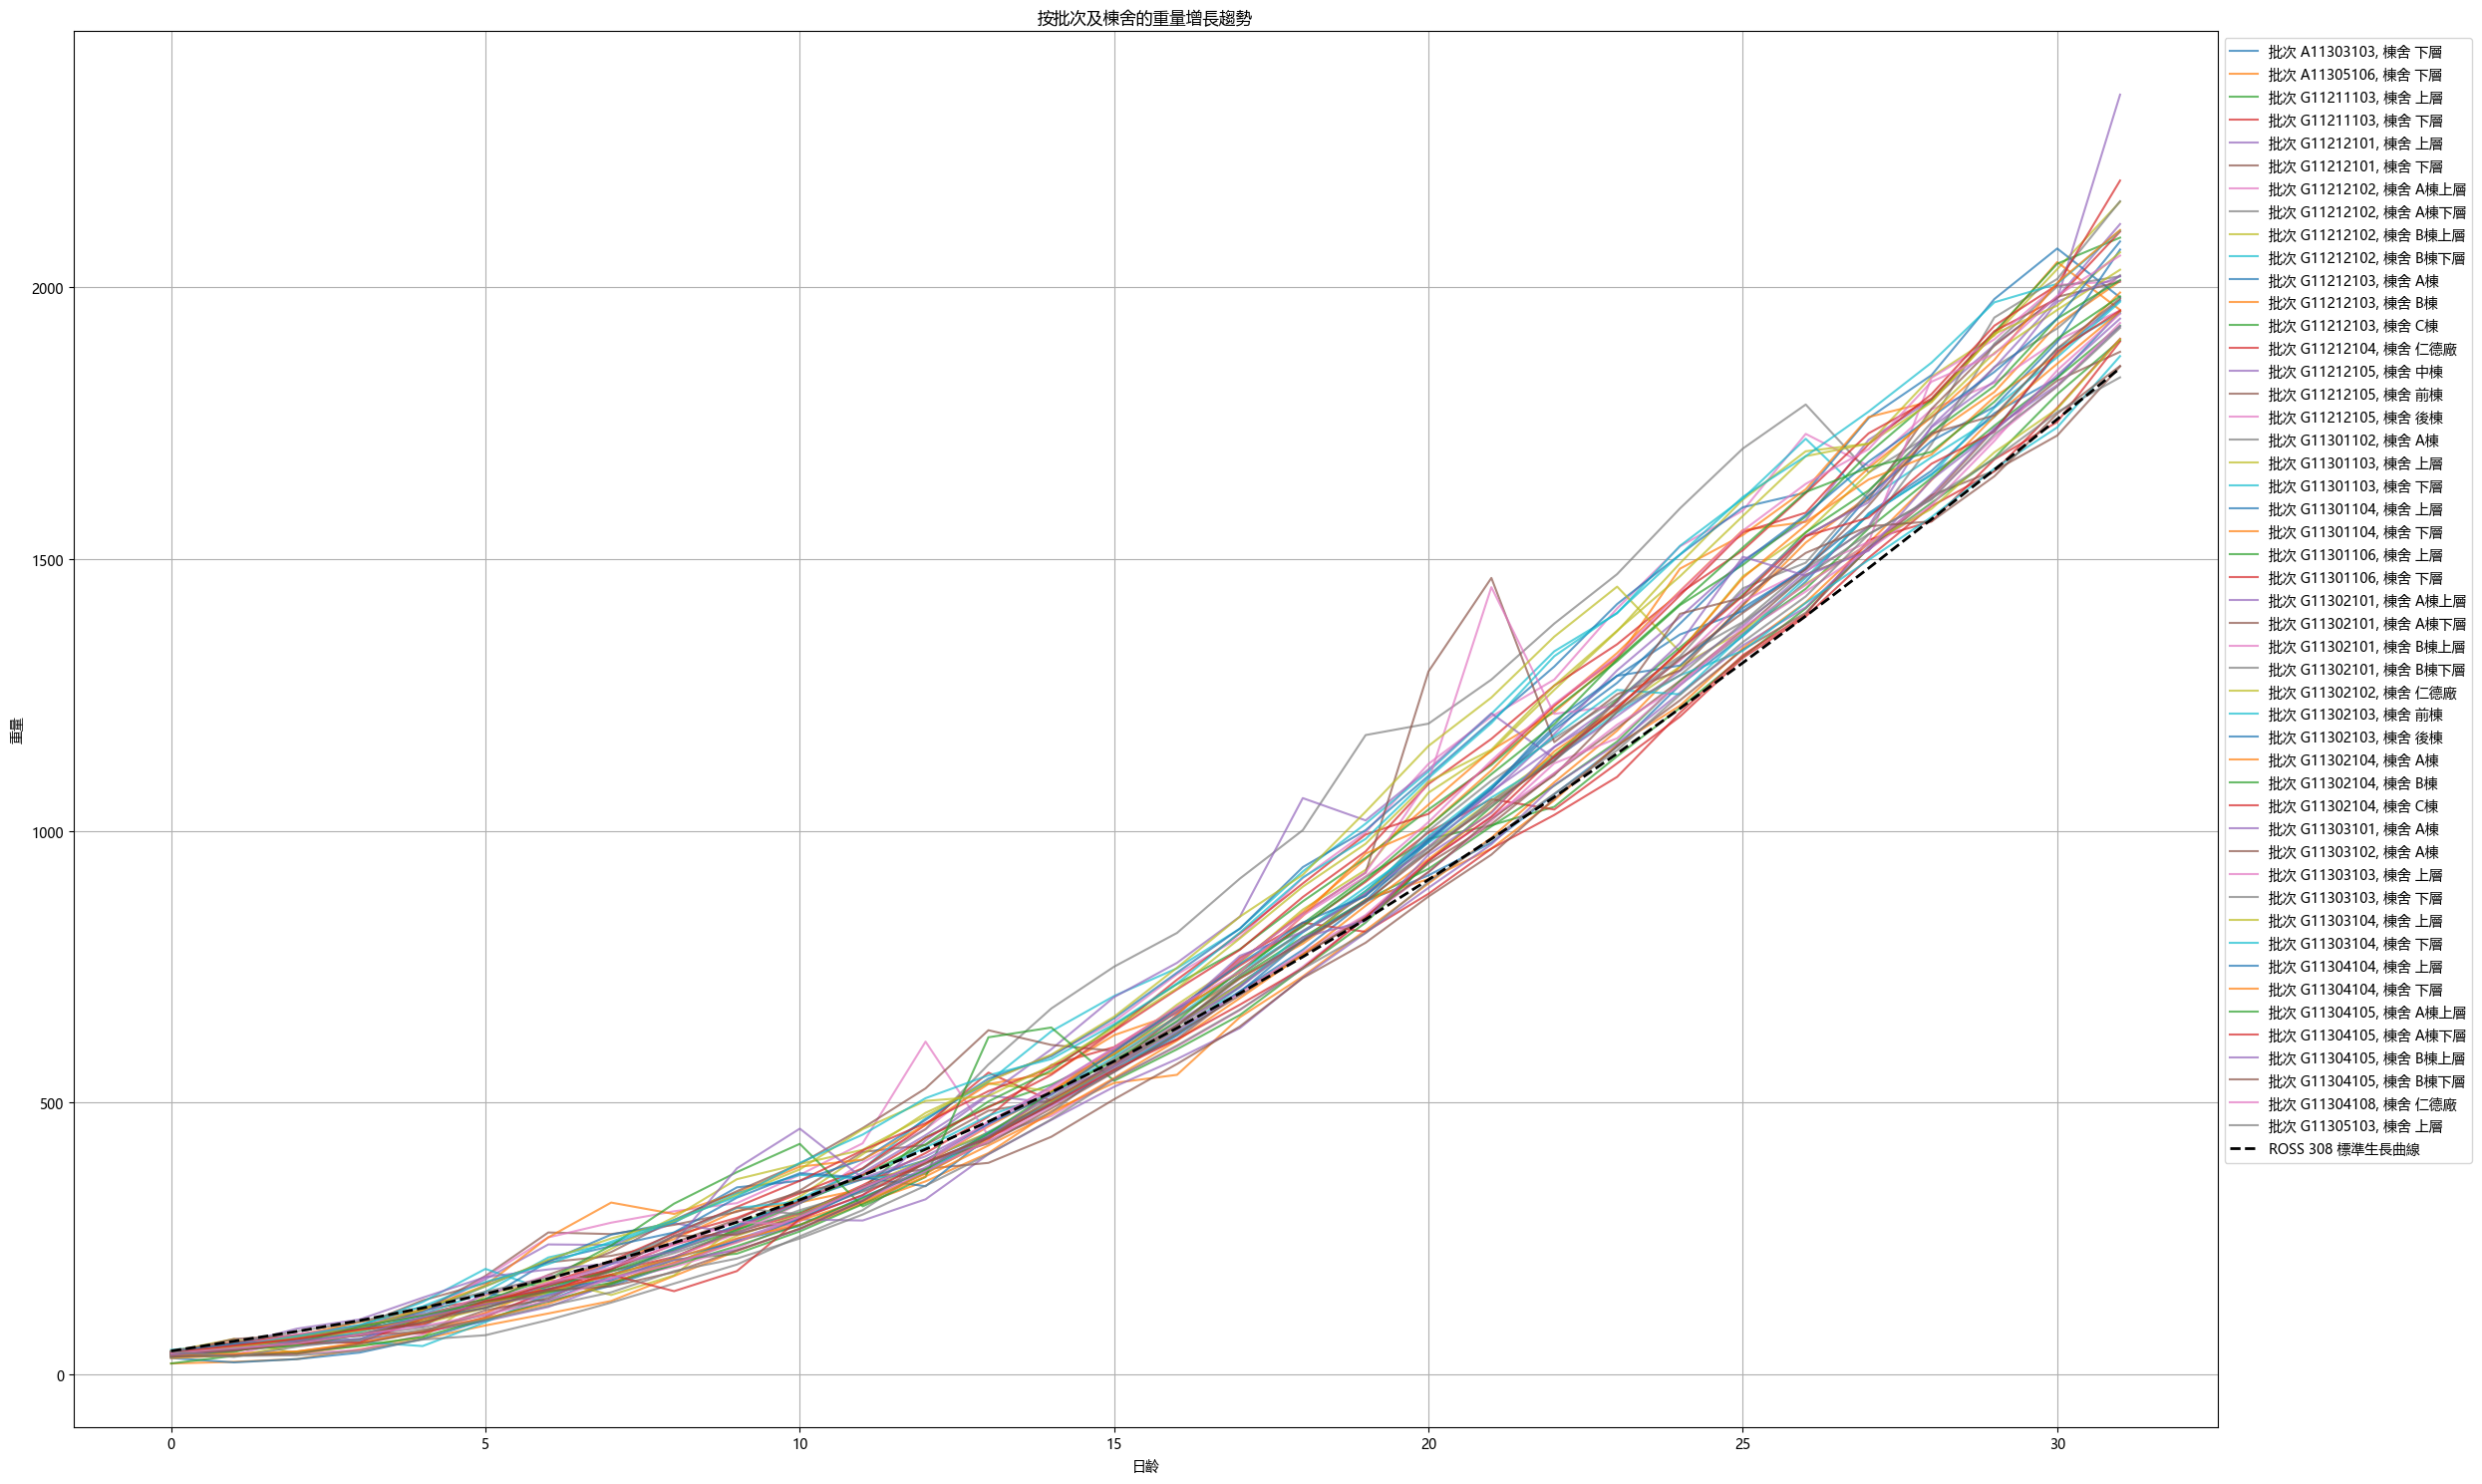

In [32]:
ages = list(range(0, 32))  # 0~31日齡
standard_data = standard_data[:32]
plot_growth_curves(df, ages=ages, standard_data=standard_data)  # 用預設的 ROSS 308 標準數據

<Figure size 4500x4500 with 0 Axes>

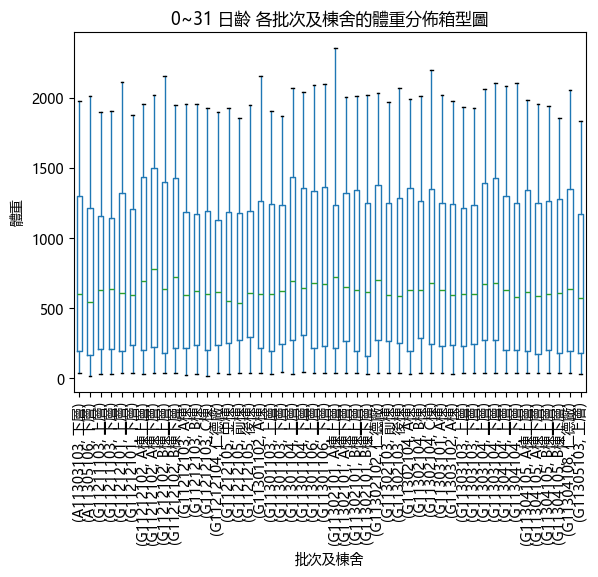

In [33]:
# 繪製箱型圖來顯示變異性
plt.figure(figsize=(45, 45))
df.boxplot(column='avg_weight', by=['chicken_import_id', 'building_number'], grid=False)
plt.title('0~31 日齡 各批次及棟舍的體重分佈箱型圖')
plt.suptitle('')  # 刪除預設的副標題
plt.xlabel('批次及棟舍')
plt.ylabel('體重')
plt.xticks(rotation=90, fontsize=10)  # 將 X 軸標籤旋轉並調整字體大小
plt.show()

<h3> 轉換資料 </h3>
<p>  # convert series to supervised learning </p>

In [34]:
df.to_csv(output_dir / "Fwusow_TargetData_growth_curve_cleaned_0_31.csv", index=False, encoding="utf-8-sig") # 之後可以改為輸出.xlsx (Excel檔案)
df

,contract_id,chicken_import_id,building_number,age,avg_weight
36,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,0,41.0
37,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,1,58.0
38,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,2,72.0
39,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,3,90.0
40,1163b6f9-48f9-4ec6-8aba-927c6e03be46,A11303103,下層,4,88.0
...,...,...,...,...,...
1707,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,27,1545.0
1708,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,28,1611.0
1709,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,29,1684.0
1710,62c0b26d-85a0-479e-8607-3e7eca0a4fe2,G11305103,上層,30,1770.0


<h3> 建立「橫向三層欄位」的生長曲線表 </h3>

In [35]:
# === 建立 pivot table ===
growth_pivot = df.pivot_table(
    index="age",
    columns=["contract_id", "chicken_import_id", "building_number"],
    values="avg_weight",
    aggfunc="mean"
)

# 依日齡由小到大排序
growth_pivot = growth_pivot.sort_index()

print("Pivot table shape:", growth_pivot.shape)
growth_pivot.to_excel(output_dir / "Fwusow_TargetData_growth_curve_matrix_0_31.xlsx", index=True)
growth_pivot

Pivot table shape: (32, 48)


contract_id       1163b6f9-48f9-4ec6-8aba-927c6e03be46            \
chicken_import_id                            A11303103 A11305106   
building_number                                     下層        下層   
age                                                                
0                                                 41.0      20.0   
1                                                 58.0      23.0   
2                                                 72.0      28.0   
3                                                 90.0      46.0   
4                                                 88.0      65.0   
5                                                149.0      90.0   
6                                                134.0     112.0   
7                                                163.0     135.0   
8                                                202.0     181.0   
9                                                246.0     227.0   
10                                               273.0     268.0   
11                                               326.0     314.0   
12                                               374.0     355.0   
13                                               440.0     407.0   
14                                               500.0     484.0   
15                                               566.0     536.0   
16                                               641.0     551.0   
17                                               719.0     657.0   
18                                               797.0     732.0   
19                                               889.0     817.0   
20                                               982.0     903.0   
21                                              1081.0     987.0   
22                                              1191.0    1089.0   
23                                              1285.0    1184.0   
24                                              1361.0    1302.0   
25                                              1404.0    1414.0   
26                                              1485.0    1530.0   
27                                              1580.0    1616.0   
28                                              1656.0    1727.0   
29                                              1736.0    1807.0   
30                                              1878.0    1931.0   
31                                              1976.0    2011.0   

contract_id       62c0b26d-85a0-479e-8607-3e7eca0a4fe2                    \
chicken_import_id                            G11211103         G11301103   
building_number                                     上層      下層        上層   
age                                                                        
0                                                 34.0    31.0      32.0   
1                                                 45.0    43.0      34.0   
2                                                 63.0    60.0      54.0   
3                                                 83.0    82.0      76.0   
4                                                103.0   119.0      93.0   
5                                                128.0   137.0     122.0   
6                                                149.0   157.0     151.0   
7                                                183.0   190.0     182.0   
8                                                215.0   216.0     203.0   
9                                                267.0   262.0     255.0   
10                                               298.0   295.0     293.0   
11                                               343.0   348.0     345.0   
12                                               436.0   407.0     395.0   
13                                               493.0   474.0     445.0   
14                                               533.0   569.0     502.0   
15                                               588.0   602.0     566.0   
16                             

<h4> 生長曲線品質檢查 </h4>

In [36]:
# === Step 6. 生長曲線品質檢查 ===
group_cols = ["contract_id", "chicken_import_id", "building_number"] # 依 contract_id + chicken_import_id + building_number 分組

def check_growth_curve(group):
    '''
    1. 依 contract_id + chicken_import_id + building_number 分組
    2. 檢查每條曲線的 age 範圍、筆數、起始/結束體重、總成長量
    3. 判斷是否嚴格遞增、是否非遞減
    4. 計算下降次數、非遞減比例
    5. 計算 max_drop、max_drop_abs、max_drop_ratio
    6. 排序後輸出品質檢查表
    '''
    group = group.sort_values("age")
    
    weights = group["avg_weight"].values.astype(float)
    ages = group["age"].values
    
    diffs = np.diff(weights)
    total_growth = weights[-1] - weights[0]
    
    # 只有真的有下降時，max_drop 才記錄負值；沒有下降則記為 0
    max_drop = float(diffs.min()) if (len(diffs) > 0 and diffs.min() < 0) else 0.0
    max_drop_abs = abs(max_drop)
    max_drop_ratio = max_drop_abs / total_growth if total_growth > 0 else np.nan
    
    result = {
        "age_min": ages.min(),
        "age_max": ages.max(),
        "n_records": len(group),
        "start_weight": weights[0],
        "end_weight": weights[-1],
        "total_growth": total_growth,
        "is_strictly_increasing": bool(np.all(diffs > 0)),
        "is_non_decreasing": bool(np.all(diffs >= 0)),
        "decrease_count": int(np.sum(diffs < 0)),
        "non_decreasing_ratio": float(np.mean(diffs >= 0)) if len(diffs) > 0 else np.nan,
        "max_drop": max_drop,
        "max_drop_abs": max_drop_abs,
        "max_drop_ratio": max_drop_ratio
    }
    return pd.Series(result)

growth_check = (
    df.groupby(group_cols)
      .apply(check_growth_curve)
      .reset_index()
)

print("總曲線數:", len(growth_check))
print("完全非遞減曲線數:", growth_check["is_non_decreasing"].sum())
print("有下降情形的曲線數:", (growth_check["decrease_count"] > 0).sum())

print("\n下降次數分布:")
print(growth_check["decrease_count"].value_counts().sort_index())

display(
    growth_check[
        ["decrease_count", "non_decreasing_ratio", "max_drop", "max_drop_abs", "max_drop_ratio", "total_growth"]
    ].describe()
)

growth_check = growth_check.sort_values(
    ["max_drop_abs", "decrease_count", "non_decreasing_ratio"],
    ascending=[False, False, True]
).reset_index(drop=True)

display(growth_check.head(10))
display(growth_check)

growth_check.to_excel(
    output_dir / "Fwusow_TargetData_growth_curve_check_0_31.xlsx",
    index=False
)

總曲線數: 48
完全非遞減曲線數: 20
有下降情形的曲線數: 28

下降次數分布:
decrease_count
0    20
1    15
2    10
3     2
4     1
Name: count, dtype: int64


C:\Users\HoChePing\AppData\Local\Temp\ipykernel_47716\4013856713.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(check_growth_curve)


,decrease_count,non_decreasing_ratio,max_drop,max_drop_abs,max_drop_ratio,total_growth
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,0.937500,0.969758,-39.750000,39.750000,0.020255,1961.375000
std,0.998003,0.032194,65.031743,65.031743,0.033070,99.327232
min,0.000000,0.870968,-302.000000,0.000000,0.000000,1792.000000
25%,0.000000,0.935484,-53.750000,0.000000,0.000000,1902.750000
50%,1.000000,0.967742,-9.000000,9.000000,0.004868,1945.500000
75%,2.000000,1.000000,0.000000,53.750000,0.028657,2019.750000
max,4.000000,1.000000,0.000000,302.000000,0.153222,2318.000000


,contract_id,chicken_import_id,building_number,age_min,age_max,n_records,start_weight,end_weight,total_growth,is_strictly_increasing,is_non_decreasing,decrease_count,non_decreasing_ratio,max_drop,max_drop_abs,max_drop_ratio
0,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,A棟下層,0,31,32,39.0,2010.0,1971.0,False,False,4,0.870968,-302.0,302.0,0.153222
1,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,0,31,32,38.0,2011.0,1973.0,False,False,2,0.935484,-233.0,233.0,0.118094
2,e8728b72-d138-49df-b469-1eafd2edd182,G11212105,後棟,0,31,32,40.0,1951.0,1911.0,False,False,2,0.935484,-173.0,173.0,0.090529
3,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11212102,A棟下層,0,31,32,38.0,2022.0,1984.0,False,False,1,0.967742,-125.0,125.0,0.063004
4,bf03e764-50bb-4e45-a670-ce10271d6626,G11302102,仁德廠,0,31,32,42.0,2032.0,1990.0,False,False,1,0.967742,-120.0,120.0,0.060302
5,8dd6be99-8c1c-427c-82dc-226189dc8b92,G11302104,B棟,0,31,32,39.0,2013.0,1974.0,False,False,2,0.935484,-115.0,115.0,0.058257
6,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11212102,B棟下層,0,31,32,37.0,1952.0,1915.0,False,False,2,0.935484,-111.0,111.0,0.057963
7,c878da16-a4df-46f9-9ce8-fd357ca7193c,G11303101,A棟,0,31,32,42.0,2020.0,1978.0,False,False,1,0.967742,-91.0,91.0,0.046006
8,eef47f04-01e7-4b49-8827-e231694ea345,G11301104,上層,0,31,32,32.0,1981.0,1949.0,False,False,1,0.967742,-90.0,90.0,0.046178
9,eef47f04-01e7-4b49-8827-e231694ea345,G11301104,下層,0,31,32,43.0,1958.0,1915.0,False,False,2,0.935484,-88.0,88.0,0.045953


,contract_id,chicken_import_id,building_number,age_min,age_max,n_records,start_weight,end_weight,total_growth,is_strictly_increasing,is_non_decreasing,decrease_count,non_decreasing_ratio,max_drop,max_drop_abs,max_drop_ratio
0,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,A棟下層,0,31,32,39.0,2010.0,1971.0,False,False,4,0.870968,-302.0,302.0,0.153222
1,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11302101,B棟上層,0,31,32,38.0,2011.0,1973.0,False,False,2,0.935484,-233.0,233.0,0.118094
2,e8728b72-d138-49df-b469-1eafd2edd182,G11212105,後棟,0,31,32,40.0,1951.0,1911.0,False,False,2,0.935484,-173.0,173.0,0.090529
3,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11212102,A棟下層,0,31,32,38.0,2022.0,1984.0,False,False,1,0.967742,-125.0,125.0,0.063004
4,bf03e764-50bb-4e45-a670-ce10271d6626,G11302102,仁德廠,0,31,32,42.0,2032.0,1990.0,False,False,1,0.967742,-120.0,120.0,0.060302
5,8dd6be99-8c1c-427c-82dc-226189dc8b92,G11302104,B棟,0,31,32,39.0,2013.0,1974.0,False,False,2,0.935484,-115.0,115.0,0.058257
6,f5db36da-e119-40db-923f-0e06f6ab5a2c,G11212102,B棟下層,0,31,32,37.0,1952.0,1915.0,False,False,2,0.935484,-111.0,111.0,0.057963
7,c878da16-a4df-46f9-9ce8-fd357ca7193c,G11303101,A棟,0,31,32,42.0,2020.0,1978.0,False,False,1,0.967742,-91.0,91.0,0.046006
8,eef47f04-01e7-4b49-8827-e231694ea345,G11301104,上層,0,31,32,32.0,1981.0,1949.0,False,False,1,0.967742,-90.0,90.0,0.046178
9,eef47f04-01e7-4b49-8827-e231694ea345,G11301104,下層,0,31,32,43.0,1958.0,1915.0,False,False,2,0.935484,-88.0,88.0,0.045953


In [37]:
# Step 2. 每日聚合 → 統計特徵
# 按照日齡把資料分組，只對 weight 欄位做計算，對每組（同一天所有雞的體重）呼叫你定義的 daily_features，算出最小值、最大值、IQR、中位數、平均數等統計特徵，最後再把 Age 從 groupby 索引還原成一般欄位，方便後續分析。
daily_stats = (
    df.groupby("age")["avg_weight"]
      .apply(daily_features)   # 每天統計
      .unstack()               # 把統計指標展開成欄位
      .reset_index()           # 把 age 從 index 拉回來
)
daily_stats

,age,min,max,range,p25,p75,IQR,median,std,mean
0,0,20.0,45.0,25.0,35.00,41.25,6.25,38.0,5.183170,37.166667
1,1,22.0,65.0,43.0,42.50,52.00,9.50,48.0,9.504175,46.395833
2,2,28.0,84.0,56.0,53.75,67.25,13.50,61.5,12.822230,58.875000
3,3,40.0,101.0,61.0,63.75,88.00,24.25,79.0,15.663347,74.750000
4,4,52.0,141.0,89.0,81.75,110.00,28.25,102.0,20.487920,98.229167
5,5,72.0,194.0,122.0,113.00,149.75,36.75,131.5,26.997997,133.291667
6,6,100.0,261.0,161.0,146.50,182.25,35.75,159.0,36.185079,167.791667
7,7,132.0,316.0,184.0,175.25,219.75,44.50,191.5,37.264955,198.562500
8,8,153.0,314.0,161.0,205.75,261.00,55.25,230.5,37.757291,234.562500
9,9,190.0,379.0,189.0,245.50,307.25,61.75,270.5,44.540677,277.145833


<h3> 正規化 （MinMaxScaler） </h3>

In [38]:
# 存檔
daily_stats.to_csv(output_dir / "Fwusow_TargetData_daily_stats_0_31.csv", index=False)
print("已輸出 Fwusow_TargetData_daily_stats_0_31.csv")

已輸出 Fwusow_TargetData_daily_stats_0_31.csv


In [39]:
# 複製一份避免覆蓋原始
df_scaled = daily_stats.copy()

<h4> 建立 scaler 並 fit_transform 特徵欄位 </h4>

In [40]:
# === Step 1. 設定 scaler 模式 ===
# SCALER_MODE = "reuse_0_21"  
# 可選：
# "fit0_31"：福壽 0~31 自己 fit scaler
# "reuse0_21" ：沿用福壽 0~21 已 fit 好的 scaler

In [41]:
# === Step 2. 指定目標與特徵欄位 ===
feature_cols = ["min","max","range","p25","p75","IQR","median","std"]
target_col = "mean"

In [42]:
# # === Step 2. 先把 DataFrame 裡的數據直接標準化 (Scaling) ===
# feature_scaler  = MinMaxScaler() # 將數據縮放到一個固定範圍內（例如 [0, 1]）。
# target_scaler  = MinMaxScaler() # 將數據縮放到一個固定範圍內（例如 [0, 1]）。

# # 特徵 scaling
# df_scaled[feature_cols] = feature_scaler.fit_transform(df_scaled[feature_cols])
# # 目標 scaling
# df_scaled[target_col] = target_scaler.fit_transform(df_scaled[[target_col]])

In [43]:
# === Step 3. 正規化 ===
if SCALER_MODE == "fit0_31":
    print("使用福壽 0~31 全資料重新 fit scaler（前期實驗版）")

    feature_scaler = MinMaxScaler()
    target_scaler = MinMaxScaler()

    df_scaled[feature_cols] = feature_scaler.fit_transform(df_scaled[feature_cols])
    df_scaled[target_col] = target_scaler.fit_transform(df_scaled[[target_col]])

    scaler_save_dir = "70%Training_30%Testing(0~31日齡_fit0_31_scaler)"

elif SCALER_MODE == "reuse0_21":
    print("沿用福壽 0~21 scaler 轉換福壽 0~31 資料")

    stageA_feature_scaler_path = Path("0~21歲日齡/70%Training_30%Testing(0~21日齡)/feature_scaler.pkl")
    stageA_target_scaler_path = Path("0~21歲日齡/70%Training_30%Testing(0~21日齡)/target_scaler.pkl")

    if not stageA_feature_scaler_path.exists():
        raise FileNotFoundError(f"找不到 feature_scaler：{stageA_feature_scaler_path}")

    if not stageA_target_scaler_path.exists():
        raise FileNotFoundError(f"找不到 target_scaler：{stageA_target_scaler_path}")

    with open(stageA_feature_scaler_path, "rb") as f:
        feature_scaler = pickle.load(f)

    with open(stageA_target_scaler_path, "rb") as f:
        target_scaler = pickle.load(f)

    df_scaled[feature_cols] = feature_scaler.transform(df_scaled[feature_cols])
    df_scaled[target_col] = target_scaler.transform(df_scaled[[target_col]])

    scaler_save_dir = "70%Training_30%Testing(0~31日齡_reuse0_21_scaler)"

else:
    raise ValueError("SCALER_MODE must be 'fit0_31' or 'reuse0_21'")

使用福壽 0~31 全資料重新 fit scaler（前期實驗版）


In [44]:
# === Step 4. 檢查正規化後範圍 ===
print("Scaled feature range:")
print(df_scaled[feature_cols].describe().loc[["min", "max"]])

print("\nScaled target range:")
print(df_scaled[target_col].describe().loc[["min", "max"]])

Scaled feature range:
     min  max  range  p25  p75  IQR  median  std
min  0.0  0.0    0.0  0.0  0.0  0.0     0.0  0.0
max  1.0  1.0    1.0  1.0  1.0  1.0     1.0  1.0

Scaled target range:
min    0.0
max    1.0
Name: mean, dtype: float64


> [!NOTE]
> 若 SCALER_MODE = "reuse0_21"，則 `22~31` 日齡的 `mean` 可能大於 `1`。  
> 這是合理的，因為是使用 `0~21` 日齡資料訓練出的 scaler，去轉換 `0~31` 日齡的後期資料。

> [!NOTE]
> 本版本為 `fit0_31_scaler` 前期實驗版，Scaler 使用 FwuSow 0～31 全資料進行 fit，再切分 train/test。  
> 此流程可作為 Stage C 補充實驗使用；若作為正式論文最嚴謹版本，後續應改為先切分 train/test，再僅使用 training set fit scaler，以避免 data leakage。

<h4> Save Dataset & 拆分資料 </h4>

In [45]:
# === Step 5. 輸出 normalized preview ===
normalized_preview_name = f"Fwusow_TargetData_daily_stats_0_31_normalized_preview_{SCALER_MODE}.csv"
df_scaled.to_csv(
    output_dir / normalized_preview_name,
    index=False,
    encoding="utf-8-sig"
)
print(f"已輸出 {normalized_preview_name}")

已輸出 Fwusow_TargetData_daily_stats_0_31_normalized_preview_fit0_31.csv


In [46]:
# === Step 6. 拆成 X 與 y ===
X = df_scaled[feature_cols].values
y = df_scaled[target_col].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32, 8)
y shape: (32,)


In [47]:
# === Step 7. Train/Test Split：前 70% 為 train，後 30% 為 test ===
split_index = int(len(df_scaled) * 0.7)

X_train, y_train = X[:split_index], y[:split_index]
X_test, y_test = X[split_index:], y[split_index:]

print("Train shape:", X_train.shape, y_train.shape)
print("Test  shape:", X_test.shape, y_test.shape)

Train shape: (22, 8) (22,)
Test  shape: (10, 8) (10,)


In [48]:
# === Step 8. 儲存成 pkl 檔案 ===
data_dic = {
    "X_train": X_train,
    "y_train": y_train,
    "X_test": X_test,
    "y_test": y_test,
    "feature_scaler": feature_scaler,  # 存下來方便 inverse_transform
    "target_scaler": target_scaler
}

In [49]:
folder_name = output_dir / scaler_save_dir
os.makedirs(folder_name, exist_ok=True)

for key, value in data_dic.items():
    file_path = os.path.join(folder_name, f"{key}.pkl")
    with open(file_path, "wb") as f:
        pickle.dump(value, f)
    print(f"已儲存：{file_path}")

已儲存：0~31日齡_fit0_31_scaler\70%Training_30%Testing(0~31日齡_fit0_31_scaler)\X_train.pkl
已儲存：0~31日齡_fit0_31_scaler\70%Training_30%Testing(0~31日齡_fit0_31_scaler)\y_train.pkl
已儲存：0~31日齡_fit0_31_scaler\70%Training_30%Testing(0~31日齡_fit0_31_scaler)\X_test.pkl
已儲存：0~31日齡_fit0_31_scaler\70%Training_30%Testing(0~31日齡_fit0_31_scaler)\y_test.pkl
已儲存：0~31日齡_fit0_31_scaler\70%Training_30%Testing(0~31日齡_fit0_31_scaler)\feature_scaler.pkl
已儲存：0~31日齡_fit0_31_scaler\70%Training_30%Testing(0~31日齡_fit0_31_scaler)\target_scaler.pkl


In [50]:
# === Step 9. Final Dataset Check ===
print("=== Final Dataset Check ===")
print("df_scaled shape:", df_scaled.shape)
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("\nFeature columns:", feature_cols)
print("Target column:", target_col)

print("\nTrain Age range:", df_scaled.iloc[:split_index]["age"].min(), "~", df_scaled.iloc[:split_index]["age"].max())
print("Test Age range :", df_scaled.iloc[split_index:]["age"].min(), "~", df_scaled.iloc[split_index:]["age"].max())

print("\nNaN check:")
print(df_scaled[feature_cols + [target_col]].isna().sum())

print("\nScaled value range:")
print(df_scaled[feature_cols + [target_col]].describe().loc[["min", "max"]])

print("SCALER_MODE:", SCALER_MODE)
print("Output folder:", folder_name)

=== Final Dataset Check ===
df_scaled shape: (32, 10)
X_train: (22, 8)
y_train: (22,)
X_test : (10, 8)
y_test : (10,)

Feature columns: ['min', 'max', 'range', 'p25', 'p75', 'IQR', 'median', 'std']
Target column: mean

Train Age range: 0 ~ 21
Test Age range : 22 ~ 31

NaN check:
min       0
max       0
range     0
p25       0
p75       0
IQR       0
median    0
std       0
mean      0
dtype: int64

Scaled value range:
     min  max  range  p25  p75  IQR  median  std  mean
min  0.0  0.0    0.0  0.0  0.0  0.0     0.0  0.0   0.0
max  1.0  1.0    1.0  1.0  1.0  1.0     1.0  1.0   1.0
SCALER_MODE: fit0_31
Output folder: 0~31日齡_fit0_31_scaler\70%Training_30%Testing(0~31日齡_fit0_31_scaler)
